<a href="https://colab.research.google.com/github/LCaravaggio/Happiness_Polarization/blob/main/Cross%20Lagged.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carga y normalización

In [1]:
!wget https://www.latinobarometro.org/documents/LAT-2024/latinobarometro-2024-stata-v20250817.zip
!unzip latinobarometro-2024-stata-v20250817.zip

!wget https://www.latinobarometro.org/documents/LAT-2023/latinobarometro-2023-stata-v1-0.zip
!unzip latinobarometro-2023-stata-v1-0.zip

!wget https://www.latinobarometro.org/documents/LAT-2020/latinobarometro-2020-esp-stata-v1-0.zip
!unzip latinobarometro-2020-esp-stata-v1-0.zip

--2026-04-17 16:33:35--  https://www.latinobarometro.org/documents/LAT-2024/latinobarometro-2024-stata-v20250817.zip
Resolving www.latinobarometro.org (www.latinobarometro.org)... 80.28.53.190
Connecting to www.latinobarometro.org (www.latinobarometro.org)|80.28.53.190|:443... connected.
HTTP request sent, awaiting response... 200 200
Length: 6691592 (6.4M) [application/x-zip-compressed]
Saving to: ‘latinobarometro-2024-stata-v20250817.zip’

latinobarometro-202 100%[===================>]   6.38M  2.58MB/s    in 2.5s    

2026-04-17 16:33:39 (2.58 MB/s) - ‘latinobarometro-2024-stata-v20250817.zip’ saved [6691592/6691592]

Archive:  latinobarometro-2024-stata-v20250817.zip
  inflating: Latinobarometro_2024_Stata_eng_v20250817.dta  
  inflating: Latinobarometro_2024_Stata_esp_v20250817.dta  
  inflating: Latinobarometro_2024_Cuestionario_esp.pdf  
  inflating: Latinobarometro_2024_Cuestionario_eng.pdf  
--2026-04-17 16:33:40--  https://www.latinobarometro.org/documents/LAT-2023/latinobaro

In [2]:
# Instala semopy si falta
import sys, subprocess, pkg_resources
required = {"semopy", "graphviz", "pandas", "numpy"}
installed = {pkg.key for pkg in pkg_resources.working_set}
missing = required - installed
if missing:
    print("Instalando:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

# Imports
import pandas as pd
import numpy as np
from semopy import Model, semplot

# 1) Cargar archivos (sin convertir value labels)
df20 = pd.read_stata("Latinobarometro_2020_Esp_Stata_v1_0.dta", convert_categoricals=False)
df23 = pd.read_stata("Latinobarometro_2023_Esp_Stata_v1_0.dta", convert_categoricals=False)
df24 = pd.read_stata("Latinobarometro_2024_Stata_esp_v20250817.dta", convert_categoricals=False)

# 2) detectar id y crear id,wave
def detect_id(df):
    for c in ["IDNUM","idnum","Idnum","id_num","NUMINVES","numinves"]:
        if c in df.columns:
            return c
    raise ValueError("No se encontró ID en la base.")
df20["id"] = df20[detect_id(df20)].astype(int)
df23["id"] = df23[detect_id(df23)].astype(int)
df24["id"] = df24[detect_id(df24)].astype(int)
df20["wave"] = 2020
df23["wave"] = 2023
df24["wave"] = 2024

/tmp/ipykernel_5059/4192479378.py:2: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import sys, subprocess, pkg_resources


Instalando: {'semopy'}


/tmp/ipykernel_5059/4192479378.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df24["id"] = df24[detect_id(df24)].astype(int)
/tmp/ipykernel_5059/4192479378.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df24["wave"] = 2024


In [3]:
# 3) mapping confirmado (usaste/confirmaste estos nombres)
mapping_2020 = {
    "p1st": "felicidad",
    "p46stgbs": "interes_politica",
    "p49stgbs": "identificacion_partidaria",
    "p18st": "polarizacion_continua",
    "p62st_d": "polarizacion_economia",
    "p20st_a": "democratico",
    "p22stm_b": "nodemocratico",
    "p9stgbs": "confianza",
    "s4": "econ_personal",
    "p4stgbs": "econ_pais",
    "edad": "edad",
    "s16": "educacion",
    "sexo": "genero",
    "idenpa": "pais"
}
mapping_2023 = {
    "P1ST": "felicidad",
    "P40STGBS": "interes_politica",
    "P42STGBS": "identificacion_partidaria",
    "P16ST": "polarizacion_continua",
    "P54ST_B": "polarizacion_economia",
    "P18ST_A": "democratico",
    "P18STM_B": "nodemocratico",
    "P9STGBS": "confianza",
    "S4": "econ_personal",
    "P4STGBS": "econ_pais",
    "edad": "edad",
    "S11": "educacion",
    "sexo": "genero",
    "idenpa": "pais"
}
mapping_2024 = {
    "P1ST": "felicidad",
    "P36STGBS": "interes_politica",
    "P26ST": "eficacia_voto",
    "P25ST": "representacion",
    "P16ST": "polarizacion_continua",
    "P33ST.D": "polarizacion_economia",
    "P38STGBS": "identificacion_partidaria",
    "P18ST.A": "democratico",
    "P18ST.B": "nodemocratico",
    "P18ST.C": "porencima",
    "P10STGBS": "confianza",
    "S4": "econ_personal",
    "P4ST": "econ_pais",
    "EDAD": "edad",
    "S11": "educacion",
    "SEXO": "genero",
    "idenpa": "pais"
}

def apply_mapping(df, mp):
    df2 = df.copy()
    not_found = []
    for raw, std in mp.items():
        if raw in df2.columns:
            df2[std] = df2[raw]
        else:
            not_found.append(raw)
    return df2, not_found

df20r, miss20 = apply_mapping(df20, mapping_2020)
df23r, miss23 = apply_mapping(df23, mapping_2023)
df24r, miss24 = apply_mapping(df24, mapping_2024)

if miss20: print("⚠️ Missing mapping 2020:", miss20)
if miss23: print("⚠️ Missing mapping 2023:", miss23)
if miss24: print("⚠️ Missing mapping 2024:", miss24)

# 4) Variables estándar a mantener (si faltan quedan NaN)
vars_std = [
    "felicidad","interes_politica","eficacia_voto","representacion", "polarizacion_economia",
    "polarizacion_continua","identificacion_partidaria","democratico","nodemocratico",
    "confianza","econ_personal","econ_pais","edad","educacion","genero", "pais"
]

def safe_slice(df, cols):
    df2 = df.copy()
    for c in cols:
        if c not in df2.columns:
            df2[c] = np.nan
    return df2[["id","wave"] + cols]

df20s = safe_slice(df20r, vars_std)
df23s = safe_slice(df23r, vars_std)
df24s = safe_slice(df24r, vars_std)

df_long = pd.concat([df20s, df23s, df24s], ignore_index=True)
print("df_long shape:", df_long.shape)

⚠️ Missing mapping 2024: ['idenpa']
df_long shape: (58623, 18)


In [4]:
# 1) Conversión explícita (idéntica a 2024)
conversion = {
    "derecha": 10,
    "izquierda": 0,
    "Ninguno": np.nan,
    "No contesta": np.nan,
    "No sabe": np.nan,
    97: np.nan,
    99: np.nan,
    "97": np.nan,
    "99": np.nan
}

def convertir(val):
    if val in conversion:
        return conversion[val]
    try:
        num = float(val)
        if num in [97, 99]:
            return np.nan
        return num
    except:
        return np.nan

# 2) Aplicar conversión solo donde existe escala ideológica
df_long["escala_lr"] = df_long["polarizacion_continua"].apply(convertir)

# 3) Distancia al centro (0–5), idéntica a 2024
df_long["polarizacion_continua"] = np.abs(df_long["escala_lr"] - 5)

# 4) Limpieza
df_long = df_long.drop(columns="escala_lr")

In [5]:
conversion = {
    3: 2,  # No muy satisfecho
    4: 1,  # Para nada satisfecho
    2: 3,  # Bastante satisfecho
    1: 4   # Muy satisfecho
}


# Reemplazar valores en la columna P1ST
df_long["felicidad"] = df_long["felicidad"].map(conversion)

# Interés en la política (1=Muy interesado ... 4=Nada interesado) → invertimos para que valores altos = más interés
df_long["interes_politica"] = df_long["interes_politica"].replace({1:4, 2:3, 3:2, 4:1})

# Sentimiento partidario (1=Sí, 2=No)
df_long["identificacion_partidaria"] = df_long["identificacion_partidaria"].replace({1:1, 2:0})

# Polarizacion económica
df_long["polarizacion_economia"] = df_long["polarizacion_economia"].replace({1:1, 2:0, 3:0, 4:1})

# Representación política (1=Sí, 2=No)
df_long["representacion"] = df_long["representacion"].replace({1:1, 2:0})

# Eficacia política (P26ST: 1=cree que su voto hace diferencia, 2=no)
df_long["eficacia_voto"] = df_long["eficacia_voto"].replace({1:1, 2:0})

In [6]:
# === 2. Conversiones ===
##################################################################
# Edad: asegurar numérico
df_long["edad"] = pd.to_numeric(df_long["edad"], errors="coerce")

##################################################################
# Género: 1 = hombre, 2 = mujer → 0/1
df_long["genero"] = df_long["genero"].replace({1: 0, 2: 1})

##################################################################
# Educación: usar S16 (1 = sin estudios ... 14 = universidad)
# Paso 1: convertir a numérico
df_long["educacion_num"] = pd.to_numeric(df_long["educacion"], errors="coerce")

# Paso 2: definir el escalador manual
def escalar_educacion(x):
    if pd.isna(x):
        return np.nan
    if x == 1:
        return 0  # sin estudios
    elif 2 <= x <= 13:
        return x - 1  # años reales (1–12)
    elif x == 14:  # universitario incompleto
        return 14
    elif x == 15:  # universitario completo
        return 16
    elif x == 16:  # técnico incompleto
        return 13
    elif x == 17:  # técnico completo
        return 14
    else:
        return np.nan

df_long["educacion"] = df_long["educacion_num"].apply(escalar_educacion)

##################################################################
# El salario o el sueldo que Ud percibe, les permite...
df_long["econ_personal"] = pd.to_numeric(df_long["econ_personal"], errors="coerce")

# Paso 2: diccionario de conversión
conv_s5 = {
    1: 4,  # les alcanza bien → muy buena situación
    2: 3,  # les alcanza justo
    3: 2,  # no les alcanza
    4: 1,  # no les alcanza, grandes dificultades
    2147483622: np.nan,  # no sabe
    2147483623: np.nan   # no contesta
}

# Paso 3: aplicar conversión
df_long["econ_personal"] = df_long["econ_personal"].replace(conv_s5)

##################################################################
# Edad al cuadrado
df_long["edad2"]=df_long["edad"]**2


##################################################################
# ¿Cómo calificaría en general la situación económica actual del país? Diría Ud. que es...?
# Paso 1: convertir P6 a numérico
df_long["econ_pais"] = pd.to_numeric(df_long["econ_pais"], errors="coerce")

# Paso 2: diccionario de conversión
# Invertimos la escala para que valores altos = percepción económica más positiva
conv_p6 = {
    1: 5,  # muy buena  → muy positiva
    2: 4,  # buena
    3: 3,  # regular
    4: 2,  # mala
    5: 1,  # muy mala → muy negativa
    2147483622: np.nan,  # no sabe
    2147483623: np.nan   # no contesta
}

# Paso 3: aplicar conversión
df_long["econ_pais"] = df_long["econ_pais"].replace(conv_p6)



##################################################################
# P10STGBS. Hablando en general, ¿Diría Ud. que se puede confiar en la mayoría de las personas o que uno nunca es lo suficientemente cuidadoso en el trato con los demás?
df_long["confianza"] = pd.to_numeric(df_long["confianza"], errors="coerce")
conv_p10 = {
    1: 1,  # Se puede confiar en la mayoría
    2: 0,  # Uno nunca es suficientemente cuidadoso
    2147483622: np.nan,  # no sabe
    2147483623: np.nan   # no contesta
}

# Paso 3: aplicar conversión
df_long["confianza"] = df_long["confianza"].replace(conv_p10)

In [7]:
vars_modelo = ["felicidad","interes_politica","eficacia_voto", "representacion",
               "polarizacion_continua","identificacion_partidaria","democratico",
               "nodemocratico", "confianza","econ_personal","econ_pais",
               "edad", "educacion","genero", "polarizacion_economia"]

tablas_por_wave = {}

for w, df_w in df_long.groupby("wave"):
    tabla = df_w[vars_modelo].describe().T
    tabla["n_miss"] = df_w[vars_modelo].isna().sum()
    tabla["%_miss"] = (tabla["n_miss"] / len(df_w) * 100).round(1)
    tablas_por_wave[w] = tabla


In [8]:
tablas_por_wave[2024]

,count,mean,std,min,25%,50%,75%,max,n_miss,%_miss
felicidad,19067.0,3.151256,0.836020,1.0,3.0,3.0,4.0,4.0,147,0.8
interes_politica,19044.0,2.047311,0.986022,1.0,1.0,2.0,3.0,4.0,170,0.9
eficacia_voto,18507.0,0.648457,0.477465,0.0,0.0,1.0,1.0,1.0,707,3.7
representacion,18467.0,0.225592,0.417983,0.0,0.0,0.0,0.0,1.0,747,3.9
polarizacion_continua,16832.0,2.458175,2.034877,0.0,0.0,2.0,5.0,5.0,2382,12.4
identificacion_partidaria,18918.0,0.338778,0.473307,0.0,0.0,0.0,1.0,1.0,296,1.5
democratico,18556.0,2.126805,0.795386,1.0,2.0,2.0,3.0,4.0,658,3.4
nodemocratico,18550.0,2.446038,0.838372,1.0,2.0,2.0,3.0,4.0,664,3.5
confianza,18843.0,0.154540,0.361475,0.0,0.0,0.0,0.0,1.0,371,1.9
econ_personal,18796.0,3.273888,1.447788,1.0,2.0,3.0,5.0,5.0,418,2.2


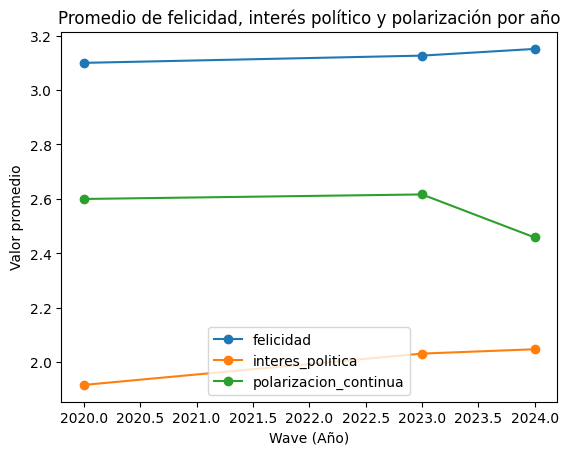

In [9]:
import matplotlib.pyplot as plt

# Variables que querés graficar
vars_plot = ["felicidad", "interes_politica", "polarizacion_continua"]

# Promedios por wave (año)
means_by_wave = df_long.groupby("wave")[vars_plot].mean()

# Gráfico
plt.figure()

for col in vars_plot:
    plt.plot(means_by_wave.index, means_by_wave[col], marker='o', label=col)

plt.xlabel("Wave (Año)")
plt.ylabel("Valor promedio")
plt.title("Promedio de felicidad, interés político y polarización por año")
plt.legend()

plt.show()

# Estandarización

In [10]:
# 5) Estadarizar por ola (z dentro de wave) para las variables que usaremos
# Variables observables que participan en el CFA
obs = ["interes_politica","identificacion_partidaria","democratico","nodemocratico","polarizacion_continua", "polarizacion_economia"
       "felicidad","eficacia_voto","representacion", "polarizacion_continua"]

for wave in [2020,2023,2024]:
    mask = df_long["wave"]==wave
    for v in obs:
        if v in df_long.columns:
            col = v
            zcol = f"{v}_{wave}_z"
            # compute z only on that wave
            s = df_long.loc[mask, col].astype(float)
            mean = s.mean(skipna=True)
            sd = s.std(skipna=True)
            if pd.isna(sd) or sd==0:
                # if no variance, fill NaN
                df_long.loc[mask, zcol] = np.nan
            else:
                df_long.loc[mask, zcol] = (s - mean) / sd

In [11]:
vars_z = [
    "felicidad", "interes_politica", "eficacia_voto", "representacion",
    "polarizacion_continua", "identificacion_partidaria", "polarizacion_economia",
    "democratico", "nodemocratico",
    "polarizacion_continua", "econ_pais", "econ_personal",
    "edad2", "confianza", "edad", "educacion"

]

for v in vars_z:
    df_long[f"{v}_z"] = np.nan

for wave in df_long["wave"].unique():
    mask = df_long["wave"] == wave
    for v in vars_z:
        s = df_long.loc[mask, v].astype(float)
        mean = s.mean(skipna=True)
        sd = s.std(skipna=True)
        if pd.isna(sd) or sd == 0:
            df_long.loc[mask, f"{v}_z"] = np.nan
        else:
            df_long.loc[mask, f"{v}_z"] = (s - mean) / sd

# Modelo por ola

In [12]:
######################## SIN CONTROLES ########################
from semopy import Model, semplot
import pandas as pd

# Subconjunto solo wave = "2024"
df = df_long[df_long["wave"] == 2024]

# Definición del modelo SEM
model_desc = """
# Variables latentes
Engagement =~ interes_politica_z +democratico_z
Polarization =~ polarizacion_continua_z + identificacion_partidaria_z + nodemocratico_z

# Relaciones estructurales
felicidad_z ~ Engagement + Polarization
"""

# Crear el modelo
model = Model(model_desc)

# Ajustar (usa FIML por defecto para manejar NaN)
model.fit(df)

# Resumen de resultados
resumen = model.inspect()
resumen

,lval,op,rval,Estimate,Std. Err,z-value,p-value
0,interes_politica_z,~,Engagement,1.000000e+00,-,-,-
1,democratico_z,~,Engagement,-3.912606e-01,0.021203,-18.453401,0.0
2,polarizacion_continua_z,~,Polarization,1.000000e+00,-,-,-
3,identificacion_partidaria_z,~,Polarization,5.393843e+00,0.598692,9.009386,0.0
4,nodemocratico_z,~,Polarization,4.045796e-02,0.038943,1.038891,0.298855
5,felicidad_z,~,Engagement,1.308614e-01,0.019871,6.585477,0.0
6,felicidad_z,~,Polarization,-1.798949e-01,0.053367,-3.370877,0.000749
7,Engagement,~~,Engagement,4.887742e-01,0.027794,17.585652,0.0
8,Engagement,~~,Polarization,6.252519e-02,0.007082,8.828782,0.0
9,Polarization,~~,Polarization,3.436729e-02,0.004456,7.712203,0.0


In [13]:
##################### CON CONTROLES #################################

model_desc = """
Engagement =~ interes_politica_z + eficacia_voto_z + representacion_z + democratico_z
Polarization =~ polarizacion_continua_z + identificacion_partidaria_z + nodemocratico_z
felicidad_z ~ Engagement + Polarization + edad_z + edad2_z + genero + educacion_z + econ_personal_z + econ_pais_z + confianza_z
"""

# Crear el modelo
model = Model(model_desc)

# Ajustar (FIML maneja NaN automáticamente)
model.fit(df)

# Resumen de resultados
Resumen = model.inspect()
resumen


,lval,op,rval,Estimate,Std. Err,z-value,p-value
0,interes_politica_z,~,Engagement,1.000000e+00,-,-,-
1,democratico_z,~,Engagement,-3.912606e-01,0.021203,-18.453401,0.0
2,polarizacion_continua_z,~,Polarization,1.000000e+00,-,-,-
3,identificacion_partidaria_z,~,Polarization,5.393843e+00,0.598692,9.009386,0.0
4,nodemocratico_z,~,Polarization,4.045796e-02,0.038943,1.038891,0.298855
5,felicidad_z,~,Engagement,1.308614e-01,0.019871,6.585477,0.0
6,felicidad_z,~,Polarization,-1.798949e-01,0.053367,-3.370877,0.000749
7,Engagement,~~,Engagement,4.887742e-01,0.027794,17.585652,0.0
8,Engagement,~~,Polarization,6.252519e-02,0.007082,8.828782,0.0
9,Polarization,~~,Polarization,3.436729e-02,0.004456,7.712203,0.0


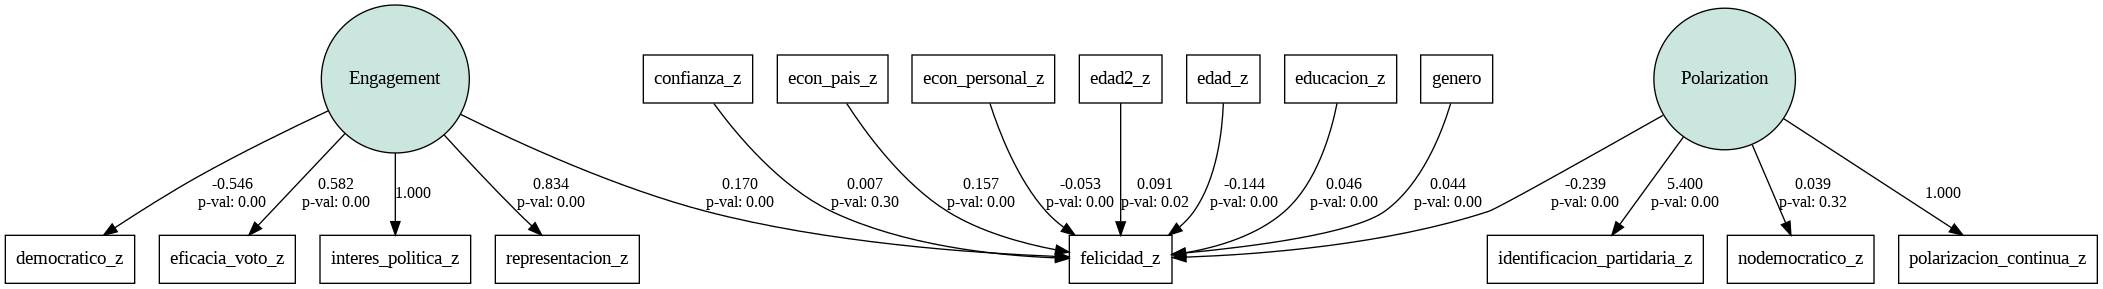

In [14]:
from IPython.display import Image
semplot(model, "diagrama_sem.png")
Image("diagrama_sem.png")

# Cross-lagged

In [15]:
############################ 1. BASELINE ############################

import statsmodels.formula.api as smf

vars_modelo = ["felicidad_z", "interes_politica_z", "polarizacion_continua_z", "pais"]

vars_all = [
    "felicidad_z","interes_politica_z","polarizacion_continua_z", "polarizacion_economia_z",
    "econ_pais_z","econ_personal_z","confianza_z", "identificacion_partidaria_z",
    "edad","educacion","pais","wave"
]

df_clean = df_long[vars_all].dropna()

baseline = smf.ols(
    """felicidad_z ~ interes_politica_z + polarizacion_continua_z""",
    data=df_clean
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_clean["pais"]}
)

print(baseline.summary())

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     8.407
Date:                Fri, 17 Apr 2026   Prob (F-statistic):            0.00289
Time:                        16:34:08   Log-Likelihood:                -49505.
No. Observations:               35058   AIC:                         9.902e+04
Df Residuals:                   35055   BIC:                         9.904e+04
Df Model:                           2                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [16]:
############################ 2. Con Controles ############################

import statsmodels.formula.api as smf

controles = smf.ols(
    """felicidad_z ~ interes_politica_z + polarizacion_continua_z
             + econ_pais_z + econ_personal_z
             + confianza_z + edad + educacion""",
    data=df_clean
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_clean["pais"]}
)

print(controles.summary())

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     16.66
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           1.82e-06
Time:                        16:34:08   Log-Likelihood:                -49157.
No. Observations:               35058   AIC:                         9.833e+04
Df Residuals:                   35050   BIC:                         9.840e+04
Df Model:                           7                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [17]:
############################ 3. FE País y Año ############################

import statsmodels.formula.api as smf

fe = smf.ols(
    """felicidad_z ~ interes_politica_z + polarizacion_continua_z
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_clean["pais"]}
)


print(fe.summary())

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     100.0
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           1.46e-12
Time:                        16:34:09   Log-Likelihood:                -48189.
No. Observations:               35058   AIC:                         9.643e+04
Df Residuals:                   35033   BIC:                         9.664e+04
Df Model:                          24                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 24, but rank is 7
  warnings.warn('covariance of constraints does not have full '


In [18]:
############################ 4. Interacción Simple ############################

import statsmodels.formula.api as smf

interaccion = smf.ols(
    """felicidad_z ~ interes_politica_z * polarizacion_continua_z
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(cov_type="cluster", cov_kwds={"groups": df_clean["pais"]})

print(interaccion.summary())

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     93.36
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           1.62e-12
Time:                        16:34:09   Log-Likelihood:                -48189.
No. Observations:               35058   AIC:                         9.643e+04
Df Residuals:                   35032   BIC:                         9.665e+04
Df Model:                          25                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 25, but rank is 8
  warnings.warn('covariance of constraints does not have full '


In [19]:
############################ 5. Descomposición ############################

import statsmodels.formula.api as smf

df_clean["polar_country_wave"] = (
    df_clean
    .groupby(["pais","wave"])["polarizacion_continua_z"]
    .transform("mean")
)

df_clean["polar_within"] = (
    df_clean["polarizacion_continua_z"] - df_clean["polar_country_wave"]
)

desc = smf.ols(
    """felicidad_z ~ polar_within + polar_country_wave
             + interes_politica_z
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(cov_type="cluster", cov_kwds={"groups": df_clean["pais"]})

print(desc.summary())

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     175.7
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           8.43e-15
Time:                        16:34:10   Log-Likelihood:                -48187.
No. Observations:               35058   AIC:                         9.643e+04
Df Residuals:                   35032   BIC:                         9.665e+04
Df Model:                          25                                         
Covariance Type:              cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.2456      0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 25, but rank is 8
  warnings.warn('covariance of constraints does not have full '


In [20]:
############################ 6. Interacción Multinivel ############################

import statsmodels.formula.api as smf

multinivel = smf.ols(
    """felicidad_z ~ polar_within + polar_country_wave
             + interes_politica_z
             + interes_politica_z:polar_within
             + interes_politica_z:polar_country_wave
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(cov_type="cluster", cov_kwds={"groups": df_clean["pais"]})

print(multinivel.summary())

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     213.6
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           7.80e-16
Time:                        16:34:11   Log-Likelihood:                -48185.
No. Observations:               35058   AIC:                         9.643e+04
Df Residuals:                   35030   BIC:                         9.666e+04
Df Model:                          27                                         
Covariance Type:              cluster                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 10
  warnings.warn('covariance of constraints does not have full '


# Tabla LaTex

In [21]:
from statsmodels.iolib.summary2 import summary_col
import pandas as pd

# -------------------------
# Modelos
# -------------------------
models = [baseline, controles, fe, interaccion, desc, multinivel]
model_names = ["(1)", "(2)", "(3)", "(4)", "(5)", "(6)"]

# -------------------------
# Renombrar variables
# -------------------------
rename_dict = {
    "interes_politica_z": "Political engagement",
    "polarizacion_continua_z": "Polarization",
    "polar_within": "Polarization (within)",
    "polar_country_wave": "Polarization (country-wave mean)",
    "interes_politica_z:polarizacion_continua_z": "Engagement × Polarization",
    "interes_politica_z:polar_within": "Engagement × Polarization (within)",
    "interes_politica_z:polar_country_wave": "Engagement × Polarization (context)"
}

# -------------------------
# Indicadores FE
# -------------------------
def has_fe(x, term):
    return "Yes" if any(term in str(p) for p in x.params.index) else "No"

info_dict = {
    "N": lambda x: f"{int(x.nobs)}",
    "R-squared": lambda x: f"{getattr(x, 'rsquared', float('nan')):.3f}",
    "Country FE": lambda x: has_fe(x, "C(pais)"),
    "Wave FE": lambda x: has_fe(x, "C(wave)")
}

# -------------------------
# Orden de variables
# -------------------------
order = [
    "interes_politica_z",
    "polarizacion_continua_z",
    "interes_politica_z:polarizacion_continua_z",
    "polar_within",
    "polar_country_wave",
    "interes_politica_z:polar_within",
    "interes_politica_z:polar_country_wave"
]

# -------------------------
# Crear tabla base
# -------------------------
table = summary_col(
    models,
    stars=True,
    float_format='%0.3f',
    model_names=model_names,
    info_dict=info_dict,
    regressor_order=order
)

df = table.tables[0].copy()

# Renombrar variables
df.index = [rename_dict.get(i, i) for i in df.index]

# Eliminar FE dummies
df = df[~df.index.str.contains("C\\(pais\\)|C\\(wave\\)", regex=True)]
df = df.loc[df.index != ""]

# -------------------------
# Manejo de duplicados
# -------------------------
df_reset = df.reset_index()
df_reset.columns = ["var"] + list(df.columns)

# Paneles
panel_A_vars = [
    "Political engagement",
    "Polarization",
    "Engagement × Polarization"
]

panel_B_vars = [
    "Polarization (within)",
    "Polarization (country-wave mean)",
    "Engagement × Polarization (within)",
    "Engagement × Polarization (context)"
]

def get_block(var_list):
    return df_reset[df_reset["var"].isin(var_list)]

panel_A = get_block(panel_A_vars)
panel_B = get_block(panel_B_vars)

used_vars = panel_A_vars + panel_B_vars
rest = df_reset[~df_reset["var"].isin(used_vars)]

def make_header(title):
    return pd.DataFrame([[title] + [""] * (df.shape[1])], columns=df_reset.columns)

# Construir tabla final
df_final = pd.concat([
    make_header("Panel A: Polarization (total)"),
    panel_A,
    make_header("Panel B: Polarization decomposition"),
    panel_B,
    rest
], ignore_index=True)

df_final = df_final.set_index("var")

# -------------------------
# FIX FINAL: limpiar y ordenar estadísticas
# -------------------------

# eliminar duplicados de R-squared
df_final = df_final[~((df_final.index == "R-squared") & (df_final.index.duplicated()))]

# orden estándar
stats_order = ["N", "R-squared", "Country FE", "Wave FE"]

coef_part = df_final.loc[~df_final.index.isin(stats_order)]
stats_part = df_final.loc[df_final.index.isin(stats_order)]

# reordenar stats
stats_part = stats_part.reindex(stats_order)

# unir
df_final = pd.concat([coef_part, stats_part])

# -------------------------
# Reemplazar tabla
# -------------------------
table.tables[0] = df_final

# -------------------------
# Exportar a LaTeX
# -------------------------
latex_table = table.as_latex()

latex_table = latex_table.replace(
    "Standard errors in parentheses.",
    "Clustered standard errors (country level) in parentheses."
)

with open("tabla_resultados.tex", "w") as f:
    f.write(latex_table)

print(latex_table)

\begin{table}
\caption{}
\label{}
\begin{center}
\begin{tabular}{lllllll}
\hline
                                    & (1)      & (2)       & (3)       & (4)       & (5)       & (6)        \\
\hline
Panel A: Polarization (total)       &          &           &           &           &           &            \\
Political engagement                & 0.038*** & 0.021**   & 0.019***  & 0.019***  & 0.018***  & 0.018***   \\
Polarization                        & -0.008   & 0.017**   & -0.001    & -0.001    &           &            \\
Engagement × Polarization           &          &           &           & -0.002    &           &            \\
Panel B: Polarization decomposition &          &           &           &           &           &            \\
Polarization (within)               &          &           &           &           & -0.002    & -0.002     \\
Polarization (country-wave mean)    &          &           &           &           & 0.132     & 0.132      \\
Engagement × Polarizatio

## Gráfico

In [22]:
b1 = multinivel.params["interes_politica_z"]
b4 = multinivel.params["interes_politica_z:polar_country_wave"]

import numpy as np

x = np.linspace(
    df_clean["polar_country_wave"].min(),
    df_clean["polar_country_wave"].max(),
    100
)

marginal_effect = b1 + b4 * x

cov = multinivel.cov_params()

var_b1 = cov.loc["interes_politica_z", "interes_politica_z"]
var_b4 = cov.loc["interes_politica_z:polar_country_wave", "interes_politica_z:polar_country_wave"]
cov_b1b4 = cov.loc["interes_politica_z", "interes_politica_z:polar_country_wave"]

se = np.sqrt(var_b1 + (x**2)*var_b4 + 2*x*cov_b1b4)

upper = marginal_effect + 1.96 * se
lower = marginal_effect - 1.96 * se

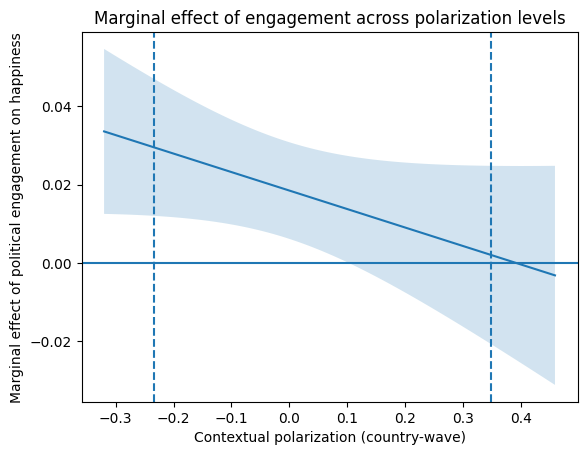

In [23]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(x, marginal_effect)
plt.fill_between(x, lower, upper, alpha=0.2)

plt.axhline(0)

p10 = np.percentile(df_clean["polar_country_wave"], 10)
p90 = np.percentile(df_clean["polar_country_wave"], 90)

plt.axvline(p10, linestyle="--")
plt.axvline(p90, linestyle="--")

plt.xlabel("Contextual polarization (country-wave)")
plt.ylabel("Marginal effect of political engagement on happiness")

plt.title("Marginal effect of engagement across polarization levels")

plt.show()

# Robustez

## Robustez de errores estándar

In [24]:
## Robustez de errores estándar
# Reestimo con clusterización por país y por pais_wave el coeficiente de -0.047* debería mantenerse

df_clean["pais_wave"] = (
    df_clean["pais"].astype(str) + "_" + df_clean["wave"].astype(str)
)

########### Modelo 3 ##############

multinivel_fe = smf.ols(
    """felicidad_z ~ interes_politica_z + polarizacion_continua_z
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_clean["pais_wave"]}
)


print(multinivel_fe.summary())

print('')
print('-----------------------')
print('Modelo 3')

print("Cluster país:")
print(fe.params["interes_politica_z"],
      fe.bse["interes_politica_z"])

print("\nCluster país-wave:")
print(multinivel_fe.params["interes_politica_z"],
      multinivel_fe.bse["interes_politica_z"])

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     1732.
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           6.87e-46
Time:                        16:34:13   Log-Likelihood:                -48189.
No. Observations:               35058   AIC:                         9.643e+04
Df Residuals:                   35033   BIC:                         9.664e+04
Df Model:                          24                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [25]:
#################### Modelo 4 ################33


multinivel_interaccion = smf.ols(
    """felicidad_z ~ interes_politica_z * polarizacion_continua_z
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(cov_type="cluster", cov_kwds={"groups": df_clean["pais_wave"]})

print(multinivel_interaccion.summary())



print('')
print('-----------------------')
print('Modelo 4')

print("Cluster país:")
print(interaccion.params["interes_politica_z"],
      interaccion.bse["interes_politica_z"])

print("\nCluster país-wave:")
print(multinivel_interaccion.params["interes_politica_z"],
      multinivel_interaccion.bse["interes_politica_z"])

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     1944.
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           7.60e-47
Time:                        16:34:14   Log-Likelihood:                -48189.
No. Observations:               35058   AIC:                         9.643e+04
Df Residuals:                   35032   BIC:                         9.665e+04
Df Model:                          25                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [26]:
########### Modelo 5 #############

multinivel_desc = smf.ols(
    """felicidad_z ~ polar_within + polar_country_wave
             + interes_politica_z
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(cov_type="cluster", cov_kwds={"groups": df_clean["pais_wave"]})

print(multinivel_desc.summary())



print('')
print('-----------------------')
print('Modelo 5')

print("Cluster país:")
print(desc.params["interes_politica_z"],
      desc.bse["interes_politica_z"])

print("\nCluster país-wave:")
print(multinivel_desc.params["interes_politica_z"],
      multinivel_desc.bse["interes_politica_z"])

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     1836.
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           2.01e-46
Time:                        16:34:15   Log-Likelihood:                -48187.
No. Observations:               35058   AIC:                         9.643e+04
Df Residuals:                   35032   BIC:                         9.665e+04
Df Model:                          25                                         
Covariance Type:              cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.2456      0

In [27]:
########### Modelo 6 ##############


multinivel_cw = smf.ols(
    """felicidad_z ~ polar_within + polar_country_wave
             + interes_politica_z
             + interes_politica_z:polar_within
             + interes_politica_z:polar_country_wave
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_clean["pais_wave"]}
)

print(multinivel_cw.summary())

print('')
print('-----------------------')
print('Modelo 6')

print("Cluster país:")
print(multinivel.params["interes_politica_z:polar_country_wave"],
      multinivel.bse["interes_politica_z:polar_country_wave"])

print("\nCluster país-wave:")
print(multinivel_cw.params["interes_politica_z:polar_country_wave"],
      multinivel_cw.bse["interes_politica_z:polar_country_wave"])

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     1758.
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           2.66e-46
Time:                        16:34:17   Log-Likelihood:                -48185.
No. Observations:               35058   AIC:                         9.643e+04
Df Residuals:                   35030   BIC:                         9.666e+04
Df Model:                          27                                         
Covariance Type:              cluster                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

## Robustez de outliers por país

In [28]:
# Saco de la muestra los países extremos en polarización

country_polar = (
    df_clean.groupby("pais")["polar_country_wave"]
    .mean()
)

p5 = country_polar.quantile(0.05)
p95 = country_polar.quantile(0.95)

outlier_countries = country_polar[
    (country_polar < p5) | (country_polar > p95)
].index

df_no_outliers = df_clean[
    ~df_clean["pais"].isin(outlier_countries)
]

multinivel_no_out = smf.ols(
    """felicidad_z ~ polar_within + polar_country_wave
             + interes_politica_z
             + interes_politica_z:polar_within
             + interes_politica_z:polar_country_wave
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_no_outliers
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_no_outliers["pais_wave"]}
)

print(multinivel_no_out.summary())

print('----------------')
print('Comparación sin países outlier')

print("Baseline:")
print(multinivel.params["interes_politica_z:polar_country_wave"],
      multinivel.bse["interes_politica_z:polar_country_wave"])

print("\nSin outliers:")
print(multinivel_no_out.params["interes_politica_z:polar_country_wave"],
      multinivel_no_out.bse["interes_politica_z:polar_country_wave"])

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     3372.
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           8.85e-47
Time:                        16:34:20   Log-Likelihood:                -44901.
No. Observations:               32660   AIC:                         8.985e+04
Df Residuals:                   32634   BIC:                         9.007e+04
Df Model:                          25                                         
Covariance Type:              cluster                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

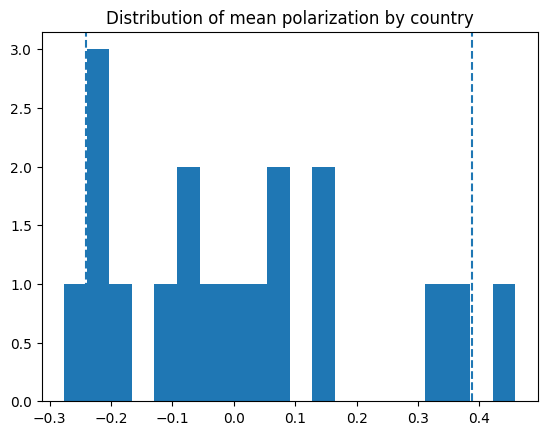

In [29]:
import matplotlib.pyplot as plt

plt.hist(country_polar, bins=20)
plt.axvline(p5, linestyle="--")
plt.axvline(p95, linestyle="--")
plt.title("Distribution of mean polarization by country")
plt.show()

In [38]:
country_map = {
    32: "Argentina",
    68: "Bolivia",
    76: "Brazil",
    152: "Chile",
    170: "Colombia",
    188: "Costa Rica",
    192: "Cuba",
    214: "Dominican Republic",
    218: "Ecuador",
    222: "El Salvador",
    320: "Guatemala",
    340: "Honduras",
    484: "Mexico",
    558: "Nicaragua",
    591: "Panama",
    600: "Paraguay",
    604: "Peru",
    858: "Uruguay",
    862: "Venezuela"
}

outliers = country_polar[(country_polar < p5) | (country_polar > p95)]

outliers.index.map(country_map)

Index(['Chile', 'Nicaragua'], dtype='object', name='pais')

## Alternativas de polarización

In [30]:
df_clean["pid_country_wave"] = (
    df_clean
    .groupby(["pais","wave"])["identificacion_partidaria_z"]
    .transform("mean")
)

df_clean["pid_within"] = (
    df_clean["identificacion_partidaria_z"] - df_clean["pid_country_wave"]
)

In [31]:
pid_model = smf.ols(
    """felicidad_z ~ pid_within + pid_country_wave
             + interes_politica_z
             + interes_politica_z:pid_within
             + interes_politica_z:pid_country_wave
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_clean["pais_wave"]}
)

print(pid_model.summary())

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                 1.775e+04
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           2.30e-63
Time:                        16:34:22   Log-Likelihood:                -48171.
No. Observations:               35058   AIC:                         9.640e+04
Df Residuals:                   35030   BIC:                         9.664e+04
Df Model:                          27                                         
Covariance Type:              cluster                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [32]:
df_clean["polar_econ_cw"] = (
    df_clean
    .groupby(["pais","wave"])["polarizacion_economia_z"]
    .transform("mean")
)

df_clean["polar_econ_within"] = (
    df_clean["polarizacion_economia_z"] - df_clean["polar_econ_cw"]
)

In [33]:
econpol_model = smf.ols(
    """felicidad_z ~ polar_econ_cw
             + interes_politica_z
             + interes_politica_z:polar_econ_cw
             + econ_pais_z + confianza_z
             + edad + educacion
             + C(pais) + C(wave)""",
    data=df_clean
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_clean["pais_wave"]}
)

print(econpol_model.summary())

                            OLS Regression Results                            
Dep. Variable:            felicidad_z   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     780.4
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           4.03e-40
Time:                        16:34:23   Log-Likelihood:                -48188.
No. Observations:               35058   AIC:                         9.643e+04
Df Residuals:                   35032   BIC:                         9.665e+04
Df Model:                          25                                         
Covariance Type:              cluster                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep